In [25]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio import AlignIO
from Bio import motifs
from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

# Q1:

**Write a function that takes a FASTA file containing sequences as input and returns the sequence IDs.**

In [16]:
def id_returner(fasta_file):
    
    recs = SeqIO.parse(fasta_file, format='fasta')
    
    ids = [r.id for r in recs]
    
    return ids

In [17]:
# Exp:
print(id_returner('/mnt/d/Bioinformatics/Seq Records & Files/11532.fasta'),
      id_returner('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta'))

['NM_004006.3'] ['NM_006996.3', 'NM_004006.3']


# Q2:

**Write a function that takes a FASTA file containing sequences as input and returns a dictionary mapping sequence IDs to sequence lengths.**

In [18]:
def seq_len_dict(fasta_file):
    
    recs = SeqIO.parse(fasta_file, format='fasta')
    
    seq_len = {}
    for r in recs:
        seq_len[r.id] = len(r.seq)
        
    return seq_len

# Exp:
seq_len_dict('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta')

{'NM_006996.3': 3612, 'NM_004006.3': 13992}

# Q3:

**Write a function that takes a FASTA file containing multiple sequences as input and copies sequences longer than 100 nucleotides into a separate FASTA file.**

In [19]:
def big_seq_identifier(fasta_file, new_destination):
    
    recs = SeqIO.parse(fasta_file, format='fasta')
    
    for r in recs:
        if len(r.seq) > 100:
            big_seq_recs = [r for r in recs]
        
    big_seq_recs = SeqIO.write(big_seq_recs, new_destination, format='fasta')
            
    return big_seq_recs

# Exp:
big_seq_identifier('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta',
                   '/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list_2.fasta')

1

# Q4:

**Write a function that takes a DNA sequence as input and returns its reverse complement.**

In [20]:
def rev_comp(dna_seq):
    
    dna_seq = Seq(dna_seq)
    
    rev_comp_seq = dna_seq.reverse_complement()
    
    return rev_comp_seq

# Q5:

**Write a function that applies a given function to each record in a file.**

In [21]:
def func_practicer(file, function, kind):
    
    with open(file) as f:
        return map(function, SeqIO.parse(f, kind))

# Q6:

**Write a command to read a file in Stockholm format.**

In [22]:
# alignment = AlignIO.read(path, format='stockholm')

# Q7:

**Given the following ten sequences, determine the consensus pattern. Then, construct the PSSM.**

"TTGACA",
"TCGACA",
"TTGACA",
"TTGAAA",
"ATGACA",
"TTGACA",
"GTGACA",
"TTGACT",
"TTGACT",
"TTGACA"

In [23]:
seqs = ['TTGACA',
        'TCGACA',
        'TTGACA',
        'TTGAAA',
        'ATGACA',
        'TTGACA',
        'GTGACA',
        'TTGACT',
        'TTGACT',
        'TTGACA']

seqs = [Seq(seq) for seq in seqs]

motif = motifs.create(seqs)

consensus = motif.consensus

pwm = motif.counts.normalize(pseudocounts=0.1)

pssm = pwm.log_odds()

print(consensus)
print(pssm)

TTGACA
        0      1      2      3      4      5
A:  -1.24  -4.70  -4.70   1.96  -1.24   1.64
C:  -4.70  -1.24  -4.70  -4.70   1.81  -4.70
G:  -1.24  -4.70   1.96  -4.70  -4.70  -4.70
T:   1.64   1.81  -4.70  -4.70  -4.70  -0.31



# Q8:

**Based on the alignment below, construct a phylogenetic tree using the UPGMA method.**

a -> TACTGCAGCTAG

b -> -TACTCAGCTA-

c -> -----CGCCTG-

d -> -TCTGCAGCTAG

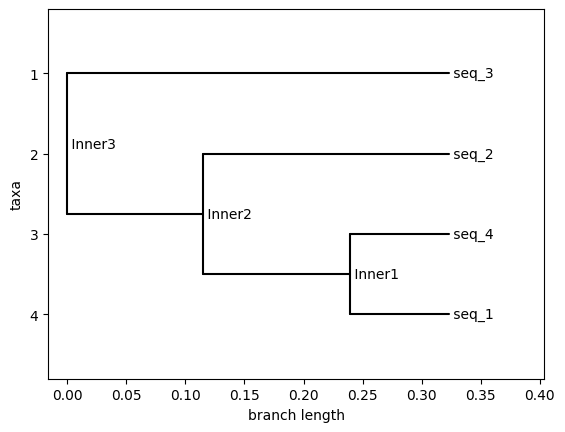

In [26]:
seqs = ['TACTGCAGCTAG',
        '-TACTCAGCTA-',
        '-----CGCCTG-',
        '-TCTGCAGCTAG']

records = []
for i, seq in enumerate(seqs, start=1):
        records.append(SeqRecord(Seq(seq), id=f'seq_{i}'))
        
records = MultipleSeqAlignment(records)

d_calc = DistanceCalculator()

tree_constructor = DistanceTreeConstructor()

distance_matrix = d_calc.get_distance(records)

phylo_tree = tree_constructor.upgma(distance_matrix)

Phylo.draw(phylo_tree)